In [1]:
pip install util-gfsilveira

In [2]:
#gerar gráfico
import matplotlib
#estruturação dos dados
import numpy as np
#gerar gráfico
import seaborn as sns
#gerar gráfico
import matplotlib.pyplot as plt
#Carregar o modelo
from keras.models import load_model
#salvar/carregar arquivos em diferentes formatos
import joblib

In [3]:
#Importando o modelo contendo os valores previstos para o número de células nas imagens
modelo_maior_erro = load_model('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens rotulo modelo - validação fluorescencia/modelo_fluore_2024-9-30.keras')
modelo_maior_erro

<Sequential name=sequential, built=True>

In [4]:
X_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens rotulo modelo - validação fluorescencia/imagens_validação_10%_fluore_2024-9-30.gz') #carregando arquivo
X_test_maior_erro.shape

(64, 300, 300, 3)

In [5]:
y_test_maior_erro = joblib.load('/content/drive/MyDrive/Projeto PEP Julia/teste/imagens_julia_quantificacao/lista de imagens e rótulos - fluorescencia/img_e_rot_para_validação_fluorescencia/imagens rotulo modelo - validação fluorescencia/rótulos_validação_10%_fluore_2024-9-30.gz') #carregando arquivo
y_test_maior_erro.shape

(64,)

In [6]:
#ROTULOS SALVOS EM LISTA

lista_observado_maior_erro = list(y_test_maior_erro)
len(lista_observado_maior_erro)

64

In [7]:
#PREDIÇÃO SALVO EM LISTA

dados_prev = modelo_maior_erro.predict(X_test_maior_erro)
lista_previsto_maior_erro = dados_prev.flatten().tolist()
len(lista_previsto_maior_erro)

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step


64

In [8]:
lista_previsto_maior_erro

[75.24390411376953,
 59.963932037353516,
 128.0557098388672,
 138.27383422851562,
 69.06813049316406,
 96.67308807373047,
 95.46122741699219,
 162.57791137695312,
 150.1357879638672,
 107.95465087890625,
 63.19172286987305,
 119.45916748046875,
 39.75974655151367,
 57.212886810302734,
 89.5084228515625,
 98.2818603515625,
 69.75218200683594,
 91.22416687011719,
 74.62808227539062,
 92.09198760986328,
 101.88642883300781,
 127.1731948852539,
 53.51933670043945,
 58.079734802246094,
 47.91412353515625,
 104.4388198852539,
 129.21432495117188,
 111.45118713378906,
 32.22316360473633,
 102.15168762207031,
 104.95410919189453,
 54.28751754760742,
 70.4607162475586,
 74.89276885986328,
 68.18036651611328,
 93.23050689697266,
 65.0656967163086,
 49.46275329589844,
 63.80855941772461,
 59.224788665771484,
 38.399471282958984,
 61.03938674926758,
 65.95758056640625,
 46.61861801147461,
 31.207252502441406,
 37.05534744262695,
 26.51272201538086,
 43.150753021240234,
 32.27516174316406,
 27.1509

In [ ]:
import pandas as pd
from scipy.stats.stats import pearsonr as stats

<ipython-input-10-b12f1aff8071>:2: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr as stats


In [ ]:
#DATAFRAME - ORGANIZAÇÃO DAS LISTAS
#COLUNA 1 ROTULO/ COLUNA 2 PREDITO

df_maior_erro = pd.DataFrame(zip(lista_observado_maior_erro,lista_previsto_maior_erro),
                             columns = ['Observed values','Lista preditos'])
df_maior_erro.head()

,Observed values,Lista preditos
0,58,75.243904
1,36,59.963932
2,123,128.055710
3,129,138.273834
4,45,69.068130


In [ ]:
#ARREDONDANDO O PREDITO ('lista preditos')

teste = round(df_maior_erro['Lista preditos'],2)
df_maior_erro['Predicted values'] = teste
df_maior_erro.head()

,Observed values,Lista preditos,Predicted values
0,58,75.243904,75.24
1,36,59.963932,59.96
2,123,128.055710,128.06
3,129,138.273834,138.27
4,45,69.068130,69.07


In [ ]:
#REORGANIZANDO AS COLUNAS

df_maior_erro = df_maior_erro.reindex(columns=['Observed values','Predicted values','Lista preditos'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos
0,58,75.24,75.243904
1,36,59.96,59.963932
2,123,128.06,128.055710
3,129,138.27,138.273834
4,45,69.07,69.068130


In [ ]:
#BIBLIOTECA CORRELAÇÃO
from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação

<ipython-input-14-b2b9a789bed1>:2: DeprecationWarning: Please import `spearmanr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import spearmanr as spearman #importando a biblioteca para gráfico de correlação


In [ ]:
# #CALCULO DE CORRELAÇÃO

col1_obt = 0 #Observed value
col2_prev = 1 #Predicted values
pear_pos_maior_erro = stats(df_maior_erro[df_maior_erro.columns[col1_obt]],
                            df_maior_erro[df_maior_erro.columns[col2_prev]])

TypeError: unsupported operand type(s) for +: 'float' and 'numpy.str_'

In [ ]:
from scipy import stats

# Verifique se as colunas contêm apenas valores numéricos
df_maior_erro[df_maior_erro.columns[col1_obt]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col1_obt]], errors='coerce')
df_maior_erro[df_maior_erro.columns[col2_prev]] = pd.to_numeric(df_maior_erro[df_maior_erro.columns[col2_prev]], errors='coerce')

# Remova as linhas com valores NaN resultantes da conversão
df_maior_erro = df_maior_erro.dropna(subset=[df_maior_erro.columns[col1_obt], df_maior_erro.columns[col2_prev]])

# Calcular a correlação
pear_pos_maior_erro = stats.pearsonr(df_maior_erro[df_maior_erro.columns[col1_obt]],
                                     df_maior_erro[df_maior_erro.columns[col2_prev]])

print(pear_pos_maior_erro)

PearsonRResult(statistic=0.9017050506681124, pvalue=2.946368414969984e-24)


<Figure size 1500x1500 with 0 Axes>

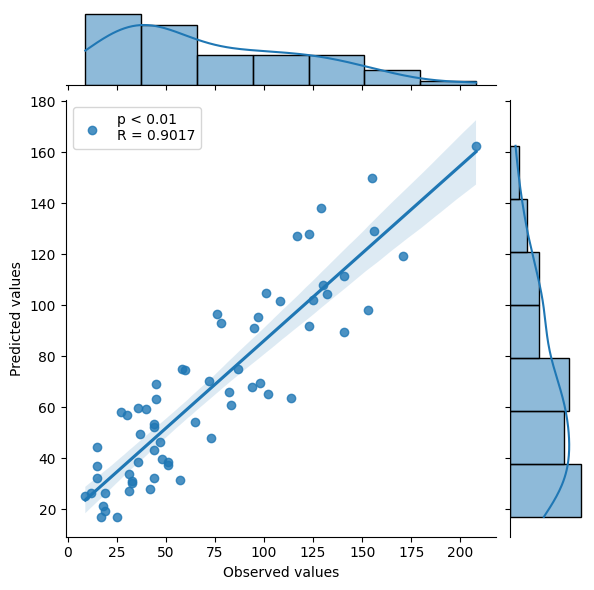

In [ ]:
plt.figure(figsize=(15,15))
sns.jointplot(
    x=df_maior_erro.columns[col1_obt],
    y=df_maior_erro.columns[col2_prev],
    kind='reg',
    data=df_maior_erro#[df_maior_erro['Lista observado'] > 300]
)

if pear_pos_maior_erro[1] < 0.01:
  plt.legend(['p < ' + '0.01' + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e relse:
else:
  plt.legend(['p = ' + str(round(pear_pos_maior_erro[1],4)) + '\nR = ' + str(round(pear_pos_maior_erro[0], 4))]) #calculando p e r

#Predição do modelo

In [ ]:
predictions = modelo_maior_erro.predict(X_test_maior_erro)

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 5s/step


In [ ]:
# Compara as previsões com os valores reais
for i in range(len(predictions)):
    print(f"Valor real: {y_test_maior_erro[i]}, Valor predito: {predictions[i]}")

Valor real: 58, Valor predito: [75.243904]
Valor real: 36, Valor predito: [59.963932]
Valor real: 123, Valor predito: [128.05571]
Valor real: 129, Valor predito: [138.27383]
Valor real: 45, Valor predito: [69.06813]
Valor real: 76, Valor predito: [96.67309]
Valor real: 97, Valor predito: [95.46123]
Valor real: 208, Valor predito: [162.57791]
Valor real: 155, Valor predito: [150.13579]
Valor real: 130, Valor predito: [107.95465]
Valor real: 45, Valor predito: [63.191723]
Valor real: 171, Valor predito: [119.45917]
Valor real: 48, Valor predito: [39.759747]
Valor real: 30, Valor predito: [57.212887]
Valor real: 141, Valor predito: [89.50842]
Valor real: 153, Valor predito: [98.28186]
Valor real: 98, Valor predito: [69.75218]
Valor real: 95, Valor predito: [91.22417]
Valor real: 60, Valor predito: [74.62808]
Valor real: 123, Valor predito: [92.09199]
Valor real: 108, Valor predito: [101.88643]
Valor real: 117, Valor predito: [127.173195]
Valor real: 44, Valor predito: [53.519337]
Valor re

#Predição de Frequência Absoluta

In [ ]:
df_maior_erro


,Observed values,Predicted values,Lista preditos
0,58,75.24,75.243904
1,36,59.96,59.963932
2,123,128.06,128.055710
3,129,138.27,138.273834
4,45,69.07,69.068130
...,...,...,...
59,51,38.72,38.724792
60,44,52.37,52.373371
61,31,33.87,33.874310
62,12,26.40,26.403498


In [ ]:
df_maior_erro['Diferença'] = df_maior_erro['Observed values'] - df_maior_erro['Predicted values']

In [ ]:
df_maior_erro

,Observed values,Predicted values,Lista preditos,Diferença
0,58,75.24,75.243904,-17.24
1,36,59.96,59.963932,-23.96
2,123,128.06,128.055710,-5.06
3,129,138.27,138.273834,-9.27
4,45,69.07,69.068130,-24.07
...,...,...,...,...
59,51,38.72,38.724792,12.28
60,44,52.37,52.373371,-8.37
61,31,33.87,33.874310,-2.87
62,12,26.40,26.403498,-14.40


In [ ]:
import matplotlib.pyplot as plt

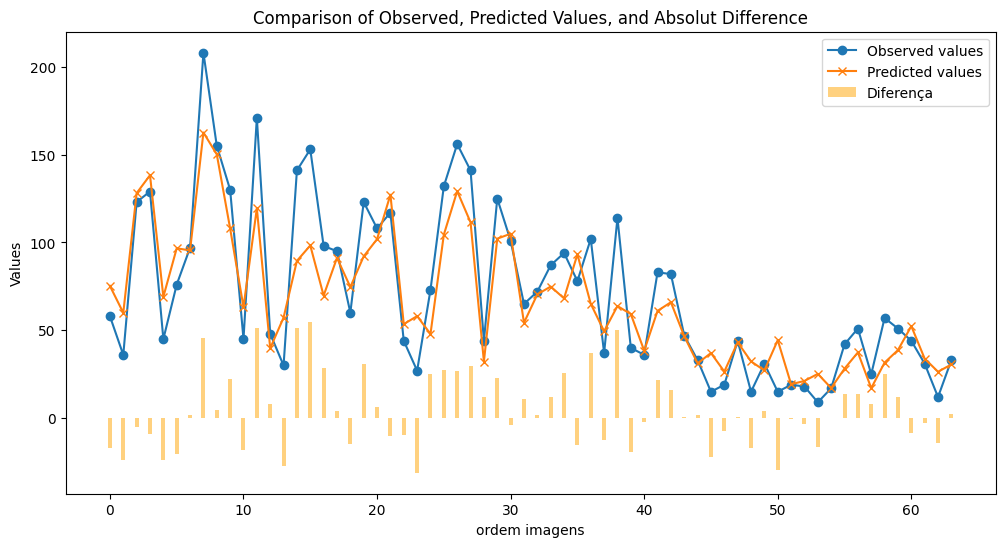

In [ ]:
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença
plt.bar(df_maior_erro.index, df_maior_erro['Diferença'], width=0.3, alpha=0.5, label='Diferença', color='orange')

# Adiciona rótulos e título
plt.xlabel('ordem imagens')
plt.ylabel('Values')
plt.title('Comparison of Observed, Predicted Values, and Absolut Difference')
plt.legend()

# Mostra o gráfico
plt.show()

**Interpretação**:
* No gráfico, você pode ver que as linhas de "Observed Values" e "Predicted Values" estão bastante próximas na maioria dos pontos, o que indica que o modelo está realizando previsões com boa precisão.
* No entanto, existem algumas discrepâncias visíveis, evidenciadas pelas barras de "Difference". As barras amarelas variam em magnitude e sinal, mostrando onde e em que medida o modelo errou.
* Quando as barras estão próximas de zero, o modelo fez previsões muito próximas dos valores reais. Já nas áreas onde as barras são mais altas ou baixas, as previsões do modelo se distanciaram dos valores observados.

**Conclusão**:
Esse gráfico permite avaliar visualmente o desempenho do modelo de regressão. A proximidade das linhas de valores observados e preditos sugere que o modelo está funcionando bem, mas as barras de diferença ajudam a identificar onde ele comete erros e quão grandes são esses erros.

#Previsão Frequência Relativa (%)

In [ ]:
#Calcula a diferença relativa entre o valor real e o valor predito (em %)
# df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Observed values'] - df_maior_erro['Predicted values']) / df_maior_erro['Observed values']) * 100
# df_maior_erro.head()

In [ ]:
df_maior_erro['Relative Difference (%)'] = ((df_maior_erro['Predicted values']*100) / df_maior_erro['Observed values'])
df_maior_erro.head()

,Observed values,Predicted values,Lista preditos,Diferença,Relative Difference (%)
0,58,75.24,75.243904,-17.24,129.724138
1,36,59.96,59.963932,-23.96,166.555556
2,123,128.06,128.055710,-5.06,104.113821
3,129,138.27,138.273834,-9.27,107.186047
4,45,69.07,69.068130,-24.07,153.488889


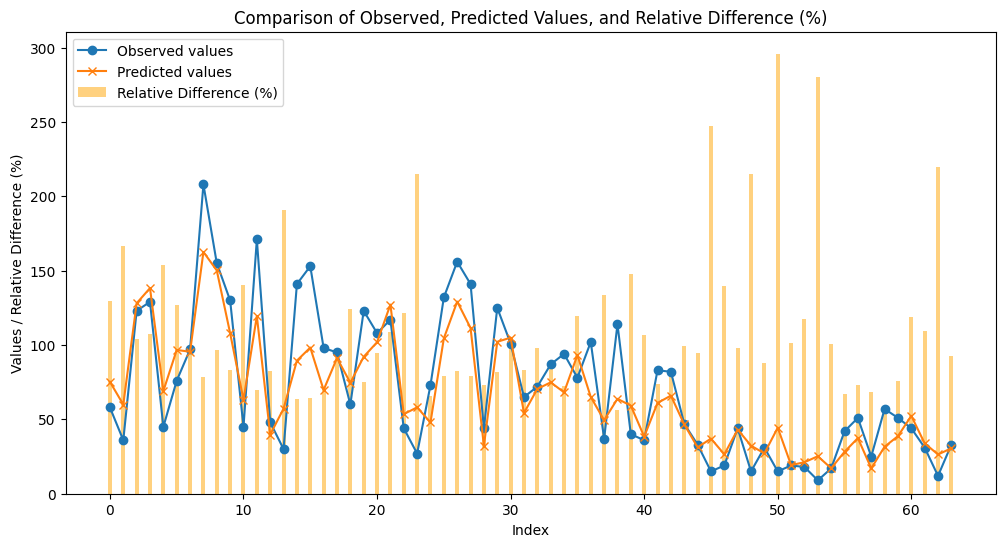

In [ ]:
# Cria o gráfico comparando os valores
plt.figure(figsize=(12, 6))

# Plotando os valores observados e preditos
plt.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o')
plt.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x')

# Adiciona a linha da diferença relativa
plt.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=0.3, alpha=0.5, label='Relative Difference (%)', color='orange')

# Adiciona rótulos e título
plt.xlabel('Index')
plt.ylabel('Values / Relative Difference (%)')
plt.title('Comparison of Observed, Predicted Values, and Relative Difference (%)')
plt.legend()

# Mostra o gráfico
plt.show()

**Explicação**:
1. Diferença Relativa: A diferença relativa é calculada dividindo a diferença absoluta pelo valor observado e multiplicando por 100 para expressá-la como uma porcentagem.
2. Gráfico de Barras para Diferença Relativa: As barras agora representam a diferença em termos percentuais (%), mostrando onde o modelo previu valores maiores ou menores em relação aos valores reais.
3. Outros Detalhes: As linhas dos valores observados e preditos permanecem as mesmas para facilitar a comparação, mas o foco aqui está nas barras de diferença relativa.

**Interpretação**:
* Esse gráfico ajudará a visualizar melhor os erros em termos proporcionais, o que é útil especialmente quando os valores observados variam bastante. A análise de erro em termos percentuais permite ver onde o modelo está errando mais, independentemente da magnitude dos valores absolutos.

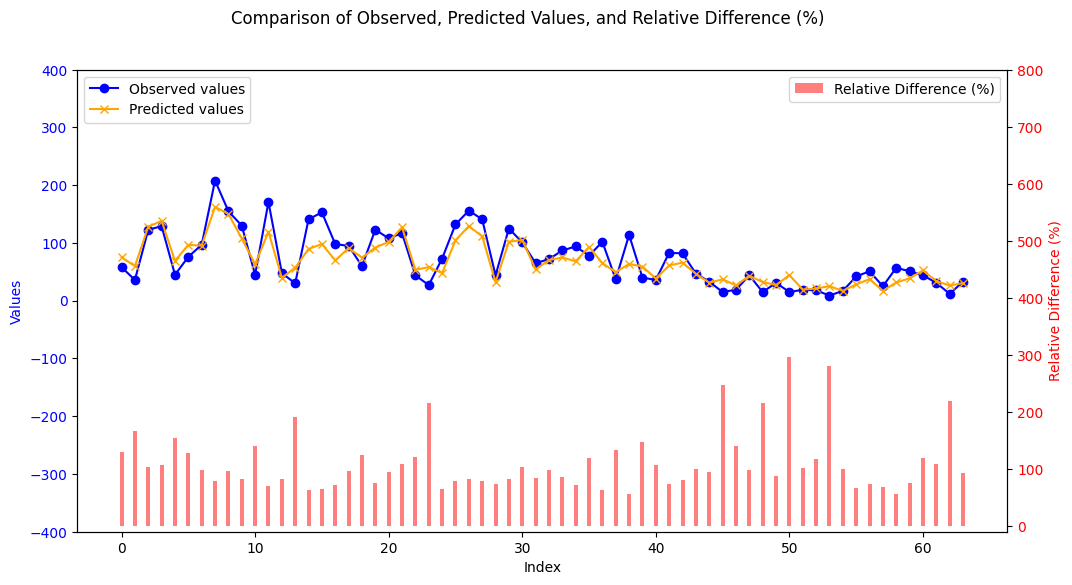

In [ ]:
# Cria o gráfico com dois eixos Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Y da esquerda (para valores observados e preditos)
ax1.set_xlabel('Index')
ax1.set_ylabel('Values', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Observed values'], label='Observed values', marker='o', color='blue')
ax1.plot(df_maior_erro.index, df_maior_erro['Predicted values'], label='Predicted values', marker='x', color='orange')
ax1.tick_params(axis='y', labelcolor='blue')

# Mantém a escala normal do eixo Y da esquerda
# ax1.set_ylim(df_maior_erro[['Observed values', 'Predicted values']].min().min(),
#              df_maior_erro[['Observed values', 'Predicted values']].max().max())
ax1.set_ylim(-400, 400)

# Adiciona o segundo eixo Y à direita (para diferença relativa)
ax2 = ax1.twinx()
ax2.set_ylabel('Relative Difference (%)', color='red')


# Ajusta a largura das barras
bar_width = 0.3
ax2.bar(df_maior_erro.index, df_maior_erro['Relative Difference (%)'], width=bar_width, alpha=0.5, label='Relative Difference (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Corrige a amplitude do eixo Y da direita para -15 a 300
ax2.set_ylim(-10, 800)

# Títulos e legendas
fig.suptitle('Comparison of Observed, Predicted Values, and Relative Difference (%)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Mostra o gráfico
plt.show()